In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
%matplotlib inline

In [13]:
# Load training set with pandas

df = pd.read_csv('data/laptops_train.csv')

X_features = ['ram_gb','storage_gb','age_years','screen_in','cpu_score','battery_health','listing_views']

X_train = df[X_features].to_numpy()
x_train = df['cpu_score'].to_numpy()
y_train = df['price'].to_numpy()

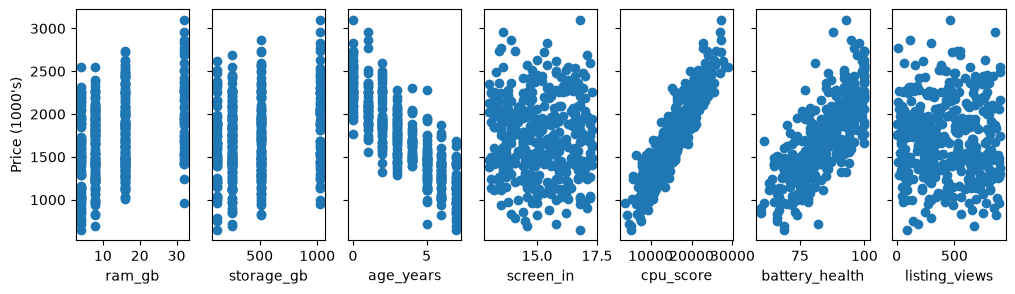

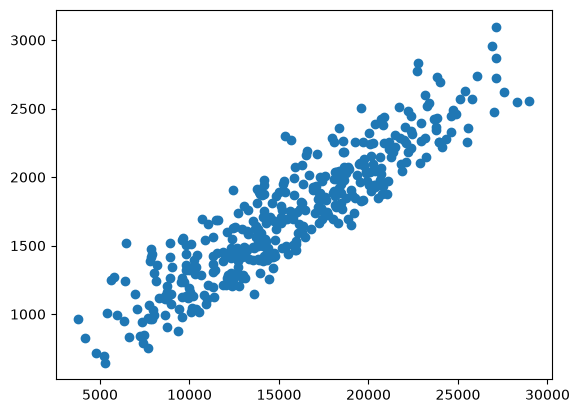

In [14]:
# Visualization of all X features and y output

fig, ax=plt.subplots(1, 7, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i], y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()

# Initial visualization of data and how cpu_score affects pricing
plt.scatter(x_train, y_train)
plt.show()

In [15]:
# Z-Score Normalization for Features
x = x_train
# Mean of each column/feature
mu = np.mean(x, axis=0)

sigma = np.std(x, axis=0)

# Final normalize x
x_norm = (x - mu) / sigma
    

In [16]:
# Compute Job Cost

def compute_cost(x, y, w, b):

    m = x.shape[0]

    total_cost = 0

    cost_sum = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost = (f_wb - y[i]) ** 2
        cost_sum = cost_sum + cost
    total_cost = (1 / (2 * m)) * cost_sum

    return total_cost

In [17]:
# Initial values for parameters w, b
initial_w = 2
initial_b = 1

cost = compute_cost(x_norm, y_train, initial_w, initial_b)
print(type(cost))
print(f"Cost at initial w: {cost:.3f}")

<class 'numpy.float64'>
Cost at initial w: 1575186.882


In [18]:
# Compute Gradient Function
def compute_gradient(x, y, w, b):

    m = x.shape[0]

    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = (f_wb - y[i])
        dj_dw += dj_dw_i
        dj_db += dj_db_i
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

In [19]:
# Initialize parameter for w, b
initial_w = 0
initial_b = 0

tmp_dj_dw, tmp_dj_db = compute_gradient(x_norm, y_train, initial_w, initial_b)
print(f'Gradient at initial w,b (zeros):', tmp_dj_dw, tmp_dj_db)


Gradient at initial w,b (zeros): -418.78203404551925 -1715.927650000001


In [20]:
def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):

    J_history = []
    w_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w, b )
        
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i < 100000:
            cost = cost_function(x, y, w, b)
            J_history.append(cost)

        if i % math.ceil(num_iters / 10) == 0:
            w_history.append(w)
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")

    return w, b, J_history, w_history

Iteration    0: Cost 1546696.00   
Iteration  150: Cost 92821.06   
Iteration  300: Cost 21521.73   
Iteration  450: Cost 18025.15   
Iteration  600: Cost 17853.67   
Iteration  750: Cost 17845.26   
Iteration  900: Cost 17844.85   
Iteration 1050: Cost 17844.83   
Iteration 1200: Cost 17844.83   
Iteration 1350: Cost 17844.83   
w,b found by gradient descent: 418.7819152555039 1715.927163266914


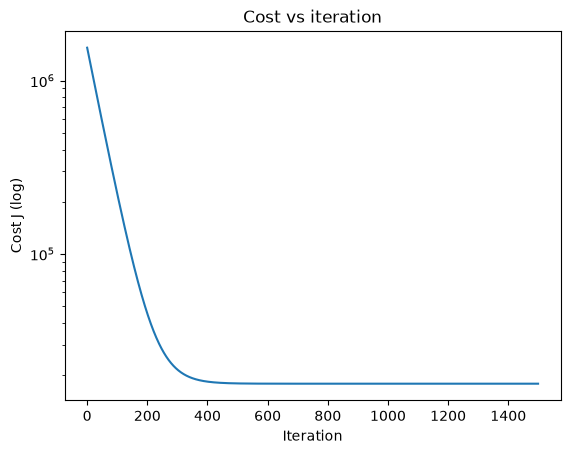

In [21]:
# Initialize fitting parameters.
initial_w = 0
initial_b = 0

iterations = 1500
alpha = 0.01

w,b,J,_ = gradient_descent(x_norm, y_train, initial_w, initial_b, compute_cost, compute_gradient, alpha, iterations)
print(f"w,b found by gradient descent:", w, b)
plt.plot(J)
plt.yscale('log')
plt.title('Cost vs iteration')
plt.xlabel('Iteration')
plt.ylabel('Cost J (log)')


plt.show()

In [22]:
# Calculate prediction with normalized values

m = x_train.shape[0]

predicted = np.zeros(m)

predicted = w * x_norm + b

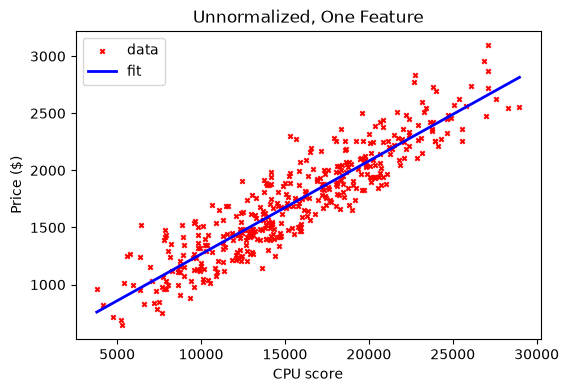

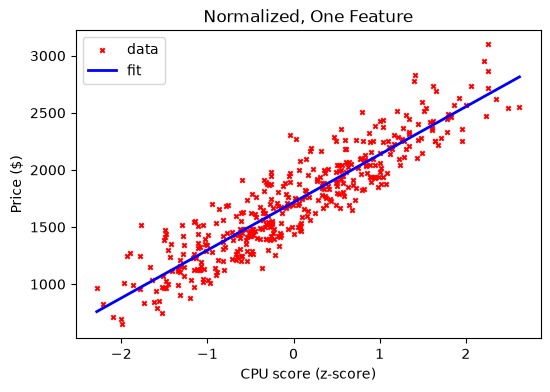

In [23]:
# Plot predicted values to see if there is a linear fit

# Unnormalized, One Feature Model
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.scatter(x_train, y_train, marker='x', s=10, c='r', label='data')
order = np.argsort(x_train)
ax1.plot(x_train[order], predicted[order], c='b', lw=2, label='fit')
ax1.set_title('Unnormalized, One Feature')
ax1.set_xlabel('CPU score')
ax1.set_ylabel('Price ($)')
ax1.legend()

# Normalized, One Feature Model
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.scatter(x_norm, y_train, marker='x', s=10, c='r', label='data')
order_n = np.argsort(x_norm)
ax2.plot(x_norm[order_n], predicted[order_n], c='b', lw=2, label='fit')
ax2.set_title('Normalized, One Feature')
ax2.set_xlabel('CPU score (z-score)')
ax2.set_ylabel('Price ($)')
ax2.legend()

plt.show()

In [24]:
# MULTIPLE REGRESSION MODEL

# Initialize X_train array of columns

X_train = df[X_features].to_numpy()

X = X_train
# Mean of each column/feature
mu = np.mean(X, axis=0)

sigma = np.std(X, axis=0)

# Final normalize x
X_norm = (X - mu) / sigma


In [25]:
# Compute Cost for Multiple Features

def compute_cost_mult(X, y, w, b):

    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb = np.dot(X[i], w) + b
        cost = cost + (f_wb - y[i]) ** 2
    cost = cost / (2 * m)
    return cost

In [26]:
# Compute cost
n = X_train.shape[1]
w_init = np.zeros(n)
b_init = 0

cost = compute_cost_mult(X_train, y_train, w_init, b_init)
print(f"Cost at optimal w: {cost}")

Cost at optimal w: 1577737.8732447498


In [27]:
# Compute gradient for multiple features
def compute_gradient_mult(X, y, w, b):

    m, n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0

    for i in range(m):
        f_wb = (np.dot(X[i], w) + b) - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + f_wb * X[i, j]
        dj_db = dj_db + f_wb
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

In [28]:
# Compute and display gradient

tmp_dj_db, tmp_dj_dw = compute_gradient_mult(X_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: [-2.46066038e+04 -8.06464925e+05 -5.09457470e+03 -2.59800235e+04
 -2.87647699e+07 -1.47559884e+05 -7.52974904e+05]
dj_dw at initial w,b: 
 -1715.927650000001


In [29]:
# Gradient Descent with multiple features
# Initialize param

n = X_train.shape[1]
w_in = np.zeros(n)
b_in = 0.
alpha = 0.01
iterations = 1000

# Before Feature Normalization
print("Raw Features")
w_raw, b_raw, J_raw, _ = gradient_descent(X_train, y_train, w_in, b_in,
                                          compute_cost_mult, compute_gradient_mult,
                                          1.0e-9, iterations)

# After Feature Normalization
print("\nNormalized Features")
w_norm, b_norm, J_norm, _ = gradient_descent(X_norm, y_train, w_in, b_in,
                                             compute_cost_mult, compute_gradient_mult,
                                             alpha, iterations)

pred_raw  = X_train @ w_raw  + b_raw
pred_norm = X_norm  @ w_norm + b_norm

print(f"MSE  raw: {np.mean((pred_raw - y_train)**2):>12,.0f}   "
      f"normalized: {np.mean((pred_norm - y_train)**2):>10,.0f}   "
      f"({np.mean((pred_raw - y_train)**2) / np.mean((pred_norm - y_train)**2):,.0f}x worse)")

Raw Features
Iteration    0: Cost 859834.41   
Iteration  100: Cost 27527.57   
Iteration  200: Cost 27364.35   
Iteration  300: Cost 27204.74   
Iteration  400: Cost 27048.68   
Iteration  500: Cost 26896.07   
Iteration  600: Cost 26746.85   
Iteration  700: Cost 26600.94   
Iteration  800: Cost 26458.25   
Iteration  900: Cost 26318.74   

Normalized Features
Iteration    0: Cost 1543693.24   
Iteration  100: Cost 200164.53   
Iteration  200: Cost 29120.10   
Iteration  300: Cost  5509.79   
Iteration  400: Cost  1943.83   
Iteration  500: Cost  1243.70   
Iteration  600: Cost  1026.50   
Iteration  700: Cost   928.76   
Iteration  800: Cost   877.41   
Iteration  900: Cost   849.15   
MSE  raw:       52,367   normalized:      1,667   (31x worse)


Unnormalized, alpha=1e-9
Iteration    0: Cost 859834.41   
Iteration  100: Cost 27527.57   
Iteration  200: Cost 27364.35   
Iteration  300: Cost 27204.74   
Iteration  400: Cost 27048.68   
Iteration  500: Cost 26896.07   
Iteration  600: Cost 26746.85   
Iteration  700: Cost 26600.94   
Iteration  800: Cost 26458.25   
Iteration  900: Cost 26318.74   

Normalized, alpha=0.01
Iteration    0: Cost 1543693.24   
Iteration  100: Cost 200164.53   
Iteration  200: Cost 29120.10   
Iteration  300: Cost  5509.79   
Iteration  400: Cost  1943.83   
Iteration  500: Cost  1243.70   
Iteration  600: Cost  1026.50   
Iteration  700: Cost   928.76   
Iteration  800: Cost   877.41   
Iteration  900: Cost   849.15   


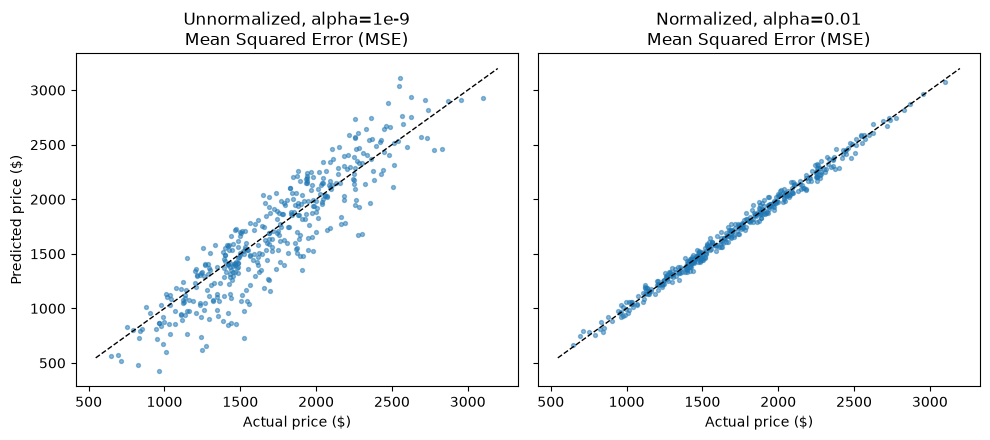

In [30]:
print("Unnormalized, alpha=1e-9")
w_r, b_r, _, _ = gradient_descent(X_train, y_train, w_in, b_in,
                                  compute_cost_mult, compute_gradient_mult, 1.0e-9, 1000)
print(f"\nNormalized, alpha={alpha}")
w_n, b_n, _, _ = gradient_descent(X_norm, y_train, w_in, b_in,
                                  compute_cost_mult, compute_gradient_mult, alpha, 1000)

fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
lims = [y_train.min() - 100, y_train.max() + 100]
for a, yh, t in zip(ax, [X_train @ w_r + b_r, X_norm @ w_n + b_n],
                    ['Unnormalized, alpha=1e-9', f'Normalized, alpha={alpha}']):
    a.scatter(y_train, yh, s=8, alpha=.5)
    a.plot(lims, lims, 'k--', lw=1)
    a.set_title(f'{t}\nMean Squared Error (MSE)')
    a.set_xlabel('Actual price ($)')
ax[0].set_ylabel('Predicted price ($)')
plt.tight_layout()
plt.show()

In [31]:
# Test Data Set and Respective Answers Comparison
X_test = pd.read_csv('data/laptops_test.csv')[X_features].to_numpy()
y_test = pd.read_csv('data/laptops_test_answers.csv')['price'].to_numpy()

pred_test = ((X_test - mu) / sigma) @ w_norm + b_norm

print(f"Test MSE: {np.mean((pred_test - y_test)**2):,.0f}   "
      f"mean error: ${np.mean(np.abs(pred_test - y_test)):,.0f}   "
      f"within $100: {np.mean(np.abs(pred_test - y_test) < 100):.0%}")

Test MSE: 1,594   mean error: $30   within $100: 98%


In [32]:
my_laptop = np.array([32, 1024, 0, 14, 35996, 100, 0])

price = ((my_laptop - mu) / sigma) @ w_norm + b_norm
print(f"Predicted price: ${price:,.2f}")

Predicted price: $3,591.49
